In [4]:
!pip install yfinance keras-tuner -q

# Импорт библиотек и настройка воспроизводимости
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping
from keras.utils import set_random_seed
import keras_tuner as kt
import warnings
warnings.filterwarnings('ignore')

# Фиксируем seed для воспроизводимости
set_random_seed(45)
np.random.seed(45)

print("Библиотеки загружены, seed зафиксирован.")

Текущая кодовая страница: 1251
Библиотеки загружены, seed зафиксирован.


In [5]:
# Загрузка временного ряда акции MU

ticker = 'MU'
start = '2015-04-01'
end   = '2016-10-01'

data = yf.download(ticker, start=start, end=end, progress=False)
data = data[['Close']].copy()
data.columns = [ticker]

print(f"Загружено строк: {len(data)}")
data.head()

Загружено строк: 380


,MU
Date,
2015-04-01,26.459538
2015-04-02,26.069424
2015-04-06,26.752125
2015-04-07,26.205971
2015-04-08,26.459538


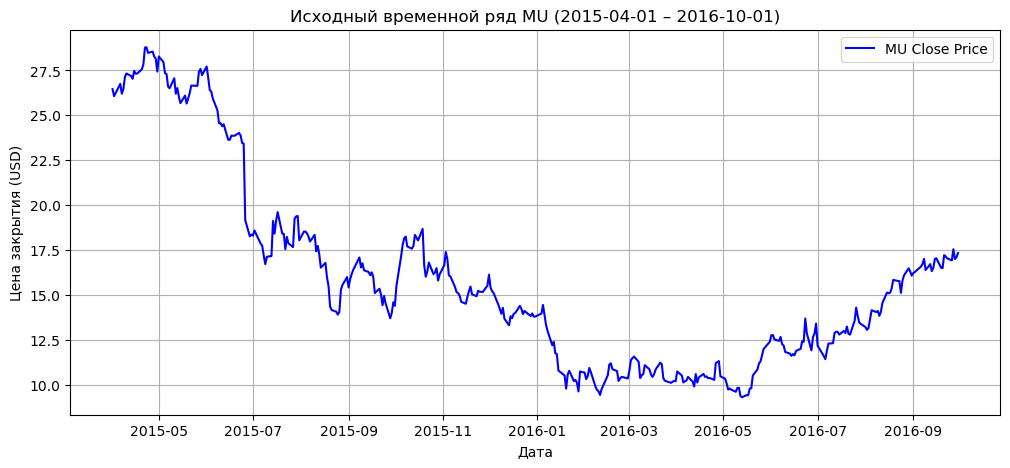

In [6]:
# Визуализация исходного ряда

plt.figure(figsize=(12,5))
plt.plot(data.index, data[ticker], label=f'{ticker} Close Price', color='blue')
plt.title(f'Исходный временной ряд {ticker} ({start} – {end})')
plt.xlabel('Дата')
plt.ylabel('Цена закрытия (USD)')
plt.grid(True)
plt.legend()
plt.show()

In [7]:
# Масштабирование данных в диапазон [0,1]

scaler = MinMaxScaler(feature_range=(0,1))
scaled_vals = scaler.fit_transform(data[[ticker]])

data_scaled = data.copy()
data_scaled[ticker] = scaled_vals

print("После масштабирования (первые 5 строк):")
data_scaled.head()

После масштабирования (первые 5 строк):


,MU
Date,
2015-04-01,0.880260
2015-04-02,0.860220
2015-04-06,0.895291
2015-04-07,0.867235
2015-04-08,0.880260


In [8]:
# Добавление столбцов с лагами от 1 до 7
# Лаг - значение временного ряда в предыд момент времени

max_lag = 7
for lag in range(1, max_lag+1):
    data_scaled[f'{ticker}_lag{lag}'] = data_scaled[ticker].shift(lag)

# Удаляем первые max_lag строк (где есть NaN)
df_model = data_scaled.dropna().copy()

# Признаки (X) – лаги, целевая переменная (y) – текущее значение
X = df_model[[f'{ticker}_lag{i}' for i in range(1, max_lag+1)]]
y = df_model[ticker]

print(f"Размер X: {X.shape}, размер y: {y.shape}")
X.head()


Размер X: (373, 7), размер y: (373,)


,MU_lag1,MU_lag2,MU_lag3,MU_lag4,MU_lag5,MU_lag6,MU_lag7
Date,,,,,,,
2015-04-13,0.924850,0.914830,0.880260,0.867235,0.895291,0.860220,0.880260
2015-04-14,0.917836,0.924850,0.914830,0.880260,0.867235,0.895291,0.860220
2015-04-15,0.909820,0.917836,0.924850,0.914830,0.880260,0.867235,0.895291
2015-04-16,0.932365,0.909820,0.917836,0.924850,0.914830,0.880260,0.867235
2015-04-17,0.924349,0.932365,0.909820,0.917836,0.924850,0.914830,0.880260


In [9]:
# Разделение выборки (временное, без перемешивания)

train_size = int(0.7 * len(X))
X_train = X.iloc[:train_size]
X_test  = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

X_train: (261, 7), y_train: (261,)
X_test:  (112, 7), y_test:  (112,)


In [10]:
# Архитектура сети (2 скрытых слоя: 30 и 20 нейронов, tanh)

model = Sequential()
model.add(Input(shape=(max_lag,)))
model.add(Dense(30, activation='tanh'))
model.add(Dense(20, activation='tanh'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 30)                  │             240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 20)                  │             620 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              21 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 881 (3.44 KB)

 Trainable params: 881 (3.44 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Запуск обучения

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=50,
    verbose=1,
    validation_data=(X_test, y_test)
)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.2377 - mae: 0.3651 - val_loss: 0.0052 - val_mae: 0.0601
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0269 - mae: 0.1393 - val_loss: 0.0313 - val_mae: 0.1705
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0391 - mae: 0.1783 - val_loss: 0.0106 - val_mae: 0.0927
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0140 - mae: 0.0993 - val_loss: 0.0026 - val_mae: 0.0432
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0133 - mae: 0.0859 - val_loss: 0.0022 - val_mae: 0.0396
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0081 - mae: 0.0694 - val_loss: 0.0020 - val_mae: 0.0354
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0072 - mae: 0.0641 - val_loss: 0.0018 - val_mae: 0.0332
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0060 - mae: 0.0582 - val_loss: 0.0025 - val_mae: 0.0395
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0057 - mae: 0.0565 - va

Тестовая выборка: MSE = 0.000752, MAE = 0.022167


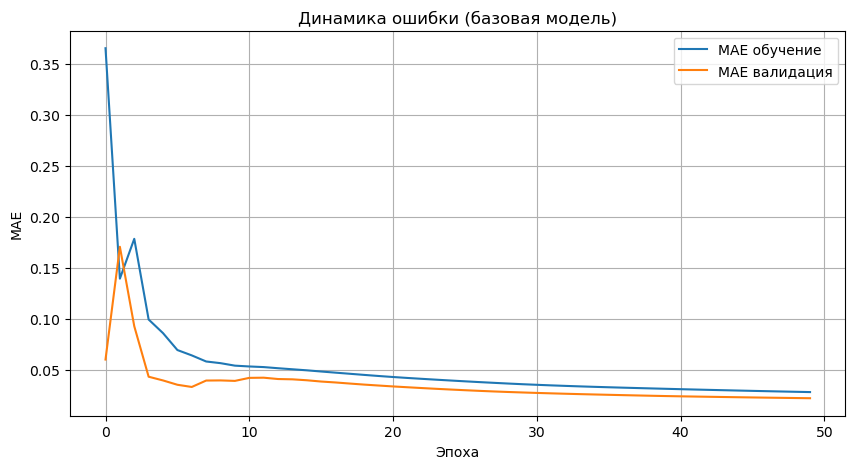

In [12]:
# Метрики на тесте и график MAE

mse, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Тестовая выборка: MSE = {mse:.6f}, MAE = {mae:.6f}")

plt.figure(figsize=(10,5))
plt.plot(history.history['mae'], label='MAE обучение')
plt.plot(history.history['val_mae'], label='MAE валидация')
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.title('Динамика ошибки (базовая модель)')
plt.legend()
plt.grid()
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


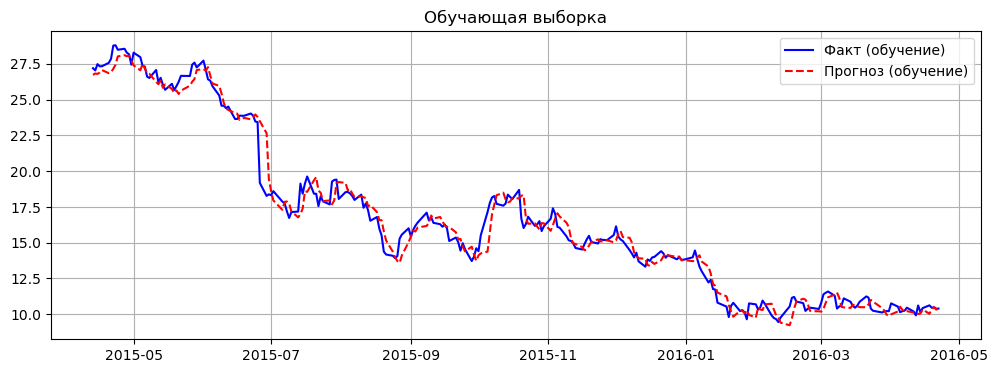

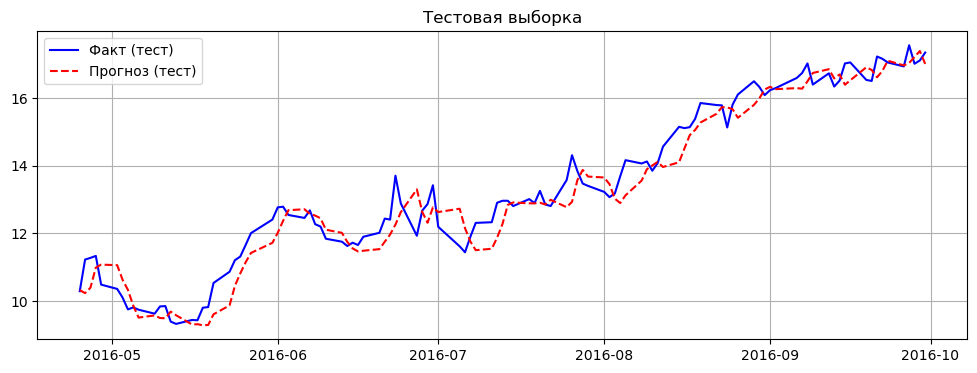

In [14]:
# Прогнозы и графики

def inverse_scale(arr):
    # Преобразуем в numpy, если передан Pandas Series
    if hasattr(arr, 'values'):
        arr = arr.values
    return scaler.inverse_transform(arr.reshape(-1, 1)).flatten()

y_train_pred = model.predict(X_train).flatten()
y_test_pred  = model.predict(X_test).flatten()

# Оригинальные цены
y_train_orig = inverse_scale(y_train)
y_test_orig  = inverse_scale(y_test)
y_train_pred_orig = inverse_scale(y_train_pred)
y_test_pred_orig  = inverse_scale(y_test_pred)

dates_train = df_model.index[:train_size]
dates_test  = df_model.index[train_size:]

# График на обучающей выборке
plt.figure(figsize=(12,4))
plt.plot(dates_train, y_train_orig, label='Факт (обучение)', color='blue')
plt.plot(dates_train, y_train_pred_orig, label='Прогноз (обучение)', color='red', linestyle='--')
plt.title('Обучающая выборка')
plt.legend()
plt.grid()
plt.show()

# График на тестовой выборке
plt.figure(figsize=(12,4))
plt.plot(dates_test, y_test_orig, label='Факт (тест)', color='blue')
plt.plot(dates_test, y_test_pred_orig, label='Прогноз (тест)', color='red', linestyle='--')
plt.title('Тестовая выборка')
plt.legend()
plt.grid()
plt.show()

In [15]:
# Ручной подбор №1 (больше нейронов, relu, rmsprop)
# Увеличение сложности модели без увеличения данных или регуляризации привело к переобучению
model1 = Sequential()
model1.add(Input(shape=(max_lag,)))
model1.add(Dense(64, activation='relu'))
model1.add(Dense(32, activation='relu'))
model1.add(Dense(1))
model1.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])

history1 = model1.fit(X_train, y_train, batch_size=32, epochs=50, verbose=0,
                      validation_data=(X_test, y_test))
mse1, mae1 = model1.evaluate(X_test, y_test, verbose=0)

print(f"Эксперимент 1: MAE = {mae1:.6f}")
# Увеличение сложности без доп данных или регуляризации привело к потере обобщающей способности

Эксперимент 1: MAE = 0.023435


In [16]:
# Ручной подбор №2 (меньше нейронов, sigmoid, adam)
model2 = Sequential()
model2.add(Input(shape=(max_lag,)))
model2.add(Dense(16, activation='sigmoid'))
model2.add(Dense(8, activation='sigmoid'))
model2.add(Dense(1))
model2.compile(optimizer='adam', loss='mse', metrics=['mae'])

history2 = model2.fit(X_train, y_train, batch_size=32, epochs=50, verbose=0,
                      validation_data=(X_test, y_test))
mse2, mae2 = model2.evaluate(X_test, y_test, verbose=0)

print(f"Эксперимент 2: MAE = {mae2:.6f}")
print(f"\nСравнение с базовой моделью (MAE = {mae:.6f}):")
print(f"  Улучшение exp1: {((mae - mae1)/mae)*100:.2f}%")
print(f"  Улучшение exp2: {((mae - mae2)/mae)*100:.2f}%")
# Слишком простая архитектура и неудачный выбор активации привели к недообучению (модель слишком слаюая для этой задачи)
# Для реального улучшения нужен систематический поиск (Keras Tuner)

Эксперимент 2: MAE = 0.036165

Сравнение с базовой моделью (MAE = 0.022167):
  Улучшение exp1: -5.72%
  Улучшение exp2: -63.15%


In [19]:
# Автоматический подбор гиперпараметров с Keras Tuner 

import shutil
import os

# Очистка предыд результатов
if os.path.exists('keras_tuner_dir'):
    shutil.rmtree('keras_tuner_dir')

# Преобразуем Series в numpy 
X_train_arr = X_train.values if hasattr(X_train, 'values') else X_train
X_test_arr = X_test.values if hasattr(X_test, 'values') else X_test
y_train_arr = y_train.values if hasattr(y_train, 'values') else y_train
y_test_arr = y_test.values if hasattr(y_test, 'values') else y_test

def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(max_lag,)))
    units1 = hp.Int('units1', 16, 128, step=16) # количество нейронов в первом скрытом слое
    units2 = hp.Int('units2', 8, 64, step=8) # количество нейронов во втором скрытом слое
    activation = hp.Choice('activation', ['relu', 'tanh', 'sigmoid'])
    optimizer = hp.Choice('optimizer', ['adam', 'rmsprop'])
    
    model.add(Dense(units1, activation=activation))
    model.add(Dense(units2, activation=activation))
    model.add(Dense(1))
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

# cлучайный поиск по заданному пространству гиперпараметров
tuner = kt.RandomSearch(
    build_model,
    objective='val_mae',
    max_trials=10,
    directory='keras_tuner_dir',
    project_name='MU_forecast'
)

tuner.search(X_train_arr, y_train_arr, epochs=30, batch_size=32,
             validation_data=(X_test_arr, y_test_arr), verbose=1)
# тюнер пробует десятки комбинаций, каждая модель обучается и оценивается на тестовом наборе, тюнер запоминает лучшую

Trial 10 Complete [00h 00m 10s]
val_mae: 0.018916217610239983

Best val_mae So Far: 0.017278503626585007
Total elapsed time: 00h 01m 28s


In [20]:
# Вывод 5 лучших моделей

best_models = tuner.get_best_models(5)
best_hps = tuner.get_best_hyperparameters(5)

for i, (model_best, hp) in enumerate(zip(best_models, best_hps)):
    print(f"\n===== Модель {i+1} =====")
    print(f"  units1: {hp.get('units1')}")
    print(f"  units2: {hp.get('units2')}")
    print(f"  activation: {hp.get('activation')}")
    print(f"  optimizer: {hp.get('optimizer')}")
    loss, mae_val = model_best.evaluate(X_test, y_test, verbose=0)
    print(f"  MAE на тесте: {mae_val:.6f}")
    model_best.summary()


===== Модель 1 =====
  units1: 48
  units2: 40
  activation: relu
  optimizer: adam
  MAE на тесте: 0.017279


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 48)                  │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 40)                  │           1,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              41 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,385 (9.32 KB)

 Trainable params: 2,385 (9.32 KB)

...

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │           1,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,569 (6.13 KB)

 Trainable params: 1,569 (6.13 KB)

 Non-trainable params: 0 (0.00 B)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


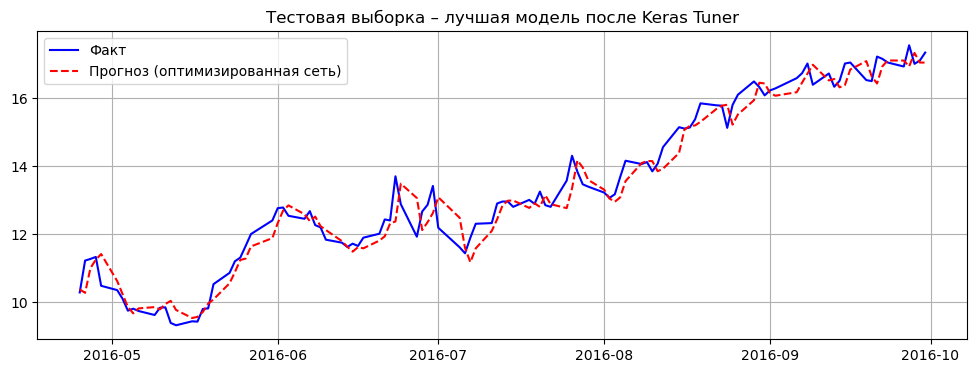

Лучшая модель: MAE = 0.017279
Улучшение относительно базовой: 22.05%


In [21]:
# Лучшая модель (первая) и её прогнозы

best_model = best_models[0]
y_pred_best = best_model.predict(X_test).flatten()
y_pred_best_orig = inverse_scale(y_pred_best)

plt.figure(figsize=(12,4))
plt.plot(dates_test, y_test_orig, label='Факт', color='blue')
plt.plot(dates_test, y_pred_best_orig, label='Прогноз (оптимизированная сеть)', color='red', linestyle='--')
plt.title('Тестовая выборка – лучшая модель после Keras Tuner')
plt.legend()
plt.grid()
plt.show()

mse_best, mae_best = best_model.evaluate(X_test, y_test, verbose=0)
print(f"Лучшая модель: MAE = {mae_best:.6f}")
print(f"Улучшение относительно базовой: {((mae - mae_best)/mae)*100:.2f}%")

In [22]:
# Эксперимент с большим лагом (14)

max_lag2 = 14
df_temp = data_scaled.copy()
for lag in range(1, max_lag2+1):
    df_temp[f'{ticker}_lag{lag}'] = df_temp[ticker].shift(lag)
df_temp = df_temp.dropna()
X2 = df_temp[[f'{ticker}_lag{i}' for i in range(1, max_lag2+1)]]
y2 = df_temp[ticker]

train_size2 = int(0.7 * len(X2))
X_train2 = X2.iloc[:train_size2]
X_test2  = X2.iloc[train_size2:]
y_train2 = y2.iloc[:train_size2]
y_test2  = y2.iloc[train_size2:]

# Используем лучшую архитектуру из предыдущего шага
model_lag = Sequential()
model_lag.add(Input(shape=(max_lag2,)))
model_lag.add(Dense(best_hps[0].get('units1'), activation=best_hps[0].get('activation')))
model_lag.add(Dense(best_hps[0].get('units2'), activation=best_hps[0].get('activation')))
model_lag.add(Dense(1))
model_lag.compile(optimizer=best_hps[0].get('optimizer'), loss='mse', metrics=['mae'])

history_lag = model_lag.fit(X_train2, y_train2, epochs=30, batch_size=32, verbose=0,
                            validation_data=(X_test2, y_test2))
mse_lag, mae_lag = model_lag.evaluate(X_test2, y_test2, verbose=0)

print(f"Модель с лагом {max_lag2}: MAE = {mae_lag:.6f}")
print(f"По сравнению с базовым лагом {max_lag}: {((mae_best - mae_lag)/mae_best)*100:.2f}%")
# Увеличение максимального лага без увеличения объёма данных или применения регуляризации ухудшает качество прогноза. 
# Оптимальное значение лага – гиперпараметр, который также можно подбирать через Keras Tuner 

Модель с лагом 14: MAE = 0.024085
По сравнению с базовым лагом 7: -39.39%


## Вывод 

1. **Базовая модель** (архитектура: 30 и 20 нейронов, `tanh`, `adam`) показала на тестовой выборке **MAE = 0.022167** (средняя ошибка прогноза около 2.2% от масштабированного диапазона).

2. **Ручной подбор гиперпараметров**:
   - Эксперимент 1 (64→32 нейрона, `relu`, `rmsprop`) → **MAE = 0.023435** (ухудшение на 5.7%).
   - Эксперимент 2 (16→8 нейронов, `sigmoid`, `adam`) → **MAE = 0.036165** (ухудшение на 63.2%).
   - Ручной подбор без систематического перебора не дал улучшения.

3. **Автоматический подбор гиперпараметров (Keras Tuner, RandomSearch)**:
   - Лучшая модель достигла **MAE = 0.017279** – улучшение на **22.05%** относительно базовой.
   - График прогноза на тестовой выборке подтверждает более точное следование тенденции.

4. **Эксперимент с увеличением максимального лага с 7 до 14**:
   - MAE вырос до **0.024085** (ухудшение на 39.4%).
   - Избыточные лаги вносят шум и мультиколлинеарность, снижая обобщающую способность.

5. **Визуальный анализ**:
   - На обучающей выборке все модели дают практически идеальное совпадение.
   - На тестовой выборке базовая модель заметно запаздывает, лучшая модель после Tuner работает точнее, но резкие локальные колебания предсказываются сглаженно – это ограничение авторегрессионных нейросетей прямого распространения.

### Итоговое заключение

- Систематическая оптимизация гиперпараметров с помощью **Keras Tuner** существенно улучшает качество прогнозирования временных рядов.
- Увеличение максимального лага сверх разумного (в варианте 7) ухудшает результат.
- Для дальнейшего повышения точности рекомендуется использовать **рекуррентные сети (LSTM, GRU)** и добавлять **регуляризацию (Dropout, Early Stopping)**.